In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [21]:
import pandas as pd
import wandb
from tqdm import tqdm

api = wandb.Api(timeout=50)

runs = api.runs("lab_frohlich/DeepMechanisticModels.v36.dream_cytof")

all_rows = []
for run in tqdm(runs):
    context = run.config.get("context")
    samples = run.config.get("samples")
    n_hidden = run.config.get("n_hidden")
    depth = run.config.get("depth")
    features = run.config.get("features")
    model = run.config.get("model")
    features_selection = run.config.get("features_selection")
    job = run.config.get("job")
    l1reg_inflater_output = run.config.get("l1reg_inflater_output")
    inflater_output_reg_epoch = run.config.get("inflater_output_reg_epoch")
    l2reg_inflater_output = run.config.get("l2reg_inflater_output")
    sparse_threshold_perc = run.config.get("sparse_threshold_perc")

    try:
        history = run.scan_history(
            keys=["rmse_train", "rmse_val", "_step"],
        )
    except Exception as e:
        print(f"Skipping run {run.id} due to error: {e}")
        continue

    for row in history:
        if row.get("rmse_train") is not None and row.get("rmse_val") is not None:
            all_rows.append({
                # Config
                "context": context,
                "samples": samples,
                "n_hidden": n_hidden,
                "depth": depth,
                "model": model,
                "features": features,
                "features_selection": features_selection,
                "job": job,
                "l1reg_inflater_output": l1reg_inflater_output,
                "inflater_output_reg_epoch": inflater_output_reg_epoch,
                "l2reg_inflater_output": l2reg_inflater_output,
                "sparse_threshold_perc": sparse_threshold_perc,
                # Epoch
                "step": row["_step"],
                # RMSEs
                "rmse_train": row["rmse_train"],
                "rmse_val": row["rmse_val"],
            })

results_df = pd.DataFrame(all_rows)
results_df.to_csv("results_model_selection_v36.csv", index=False)

 28%|██▊       | 63/225 [00:47<02:03,  1.31it/s]

KeyboardInterrupt



In [23]:
df = pd.read_csv("results_model_selection_v36.csv")
results_df.head()

,context,samples,n_hidden,depth,model,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val
0,cytof_init,0of5,2,0,EGFR_MAPK_freeeq_tobs,RFE_10_permute,None,0,62.5,100,0,gmm,1,0.523885,0.784088
1,cytof_init,0of5,2,0,EGFR_MAPK_freeeq_tobs,RFE_10_permute,None,0,62.5,100,0,gmm,13,0.508871,0.814711
2,cytof_init,0of5,2,0,EGFR_MAPK_freeeq_tobs,RFE_10_permute,None,0,62.5,100,0,gmm,26,0.490293,0.673623
3,cytof_init,0of5,2,0,EGFR_MAPK_freeeq_tobs,RFE_10_permute,None,0,62.5,100,0,gmm,36,0.478901,0.650442
4,cytof_init,0of5,2,0,EGFR_MAPK_freeeq_tobs,RFE_10_permute,None,0,62.5,100,0,gmm,50,0.470331,0.614264


In [24]:
order = df[df['step']==499][['model', 'rmse_val']].groupby(['model']).aggregate(
    {'rmse_val': 'mean'}).sort_values('rmse_val').index.tolist()
order

['EGFR_MAPK_tegfr',
 'EGFR_MAPK_terbb2_tegfr',
 'EGFR_MAPK_freeeq',
 'EGFR_MAPK',
 'EGFR_MAPK_pegfr',
 'EGFR_MAPK_terbb2',
 'EGFR_MAPK_perbb2_pegfr',
 'EGFR_MAPK_perbb2',
 'EGFR_MAPK_freeeq_tobs']

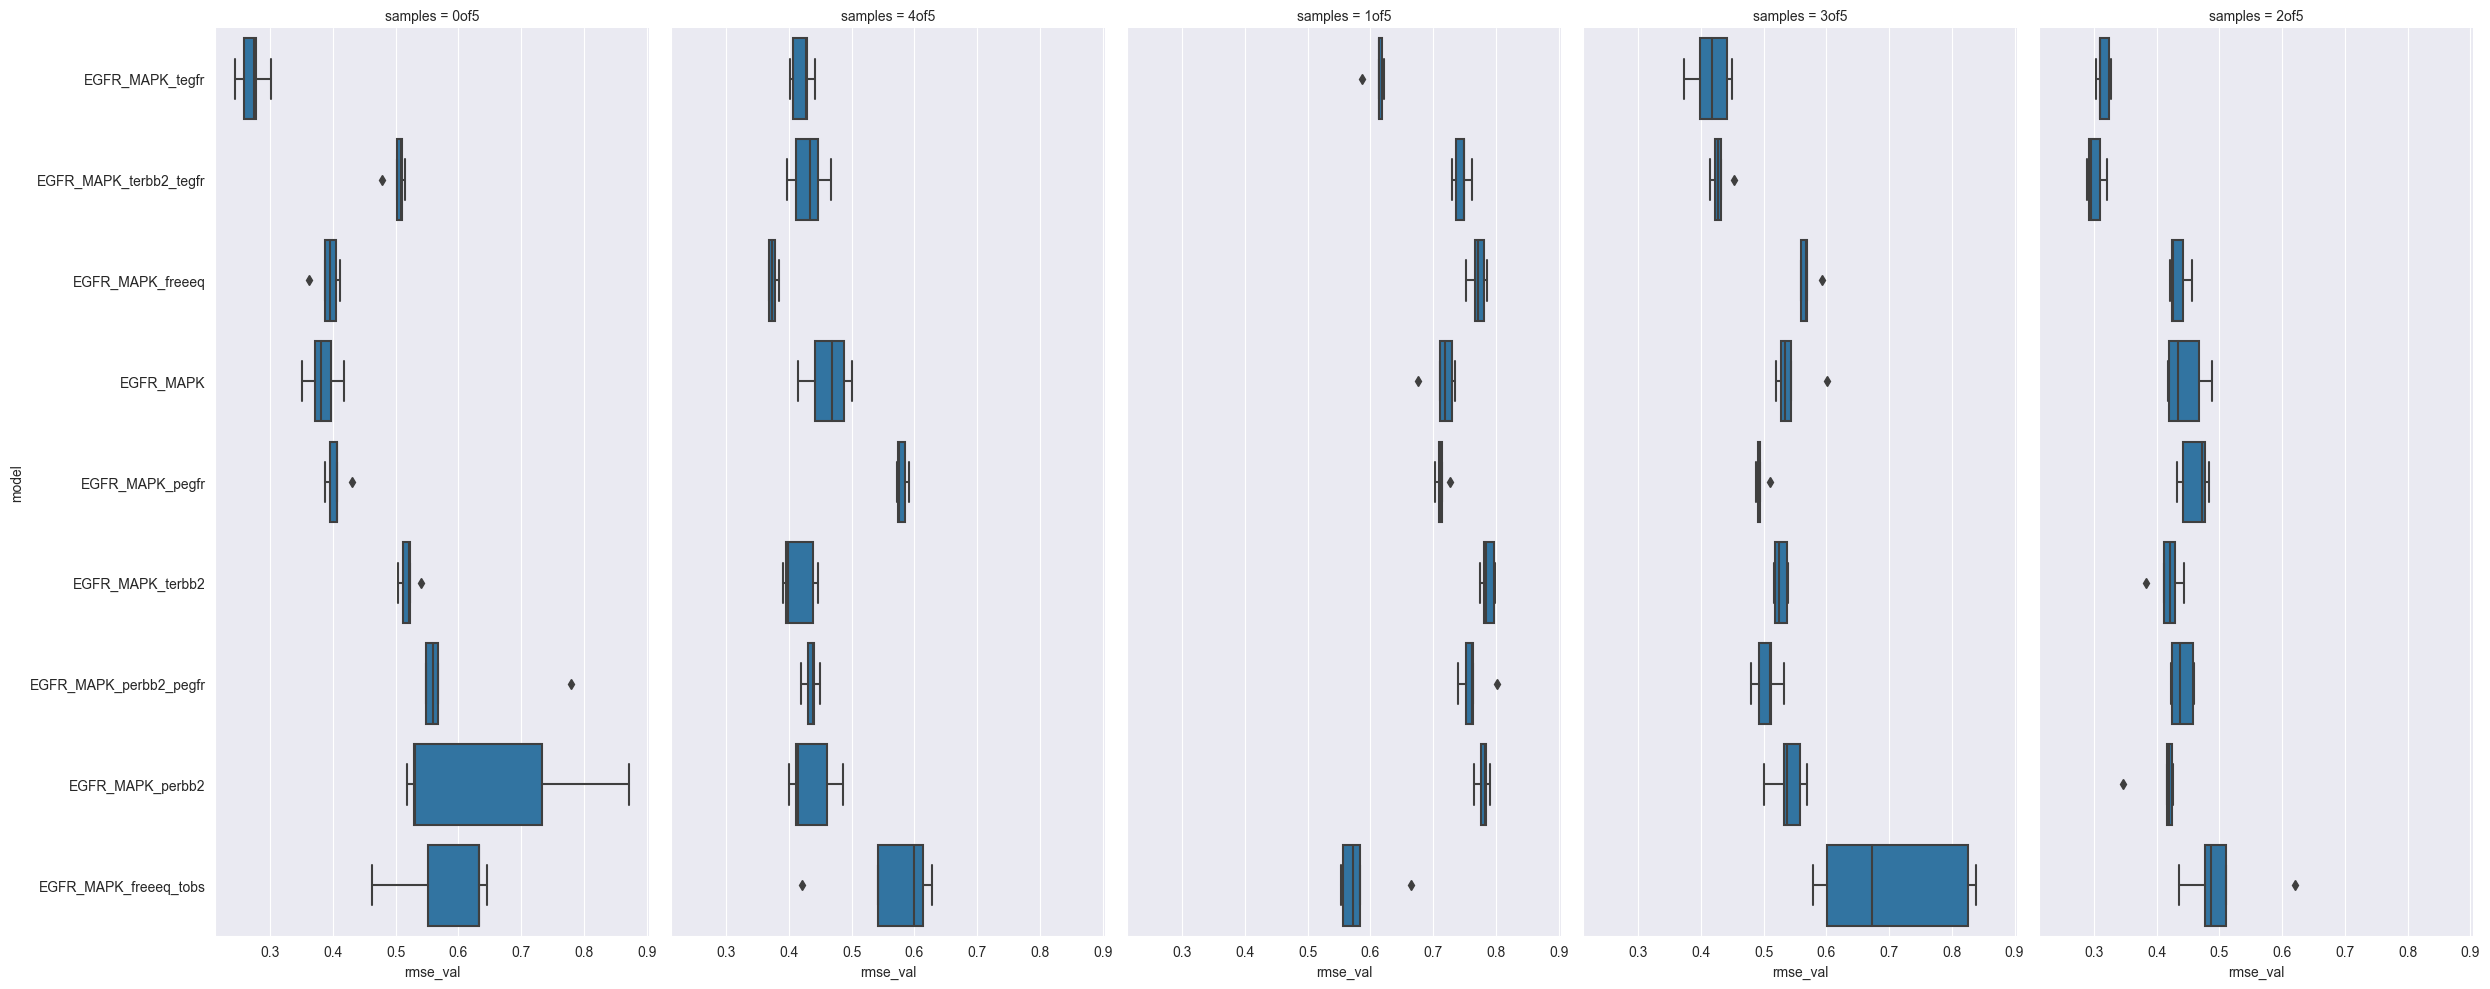

In [25]:
g = sns.FacetGrid(
    df[df['step']==499],
    col='samples',
    margin_titles=True,
    sharey=True,
    sharex=True,
    height=10,
    aspect=0.5
)
g.map_dataframe(
    sns.boxplot,
    y='model',
    x='rmse_val',
    order=order,
)
plt.show()

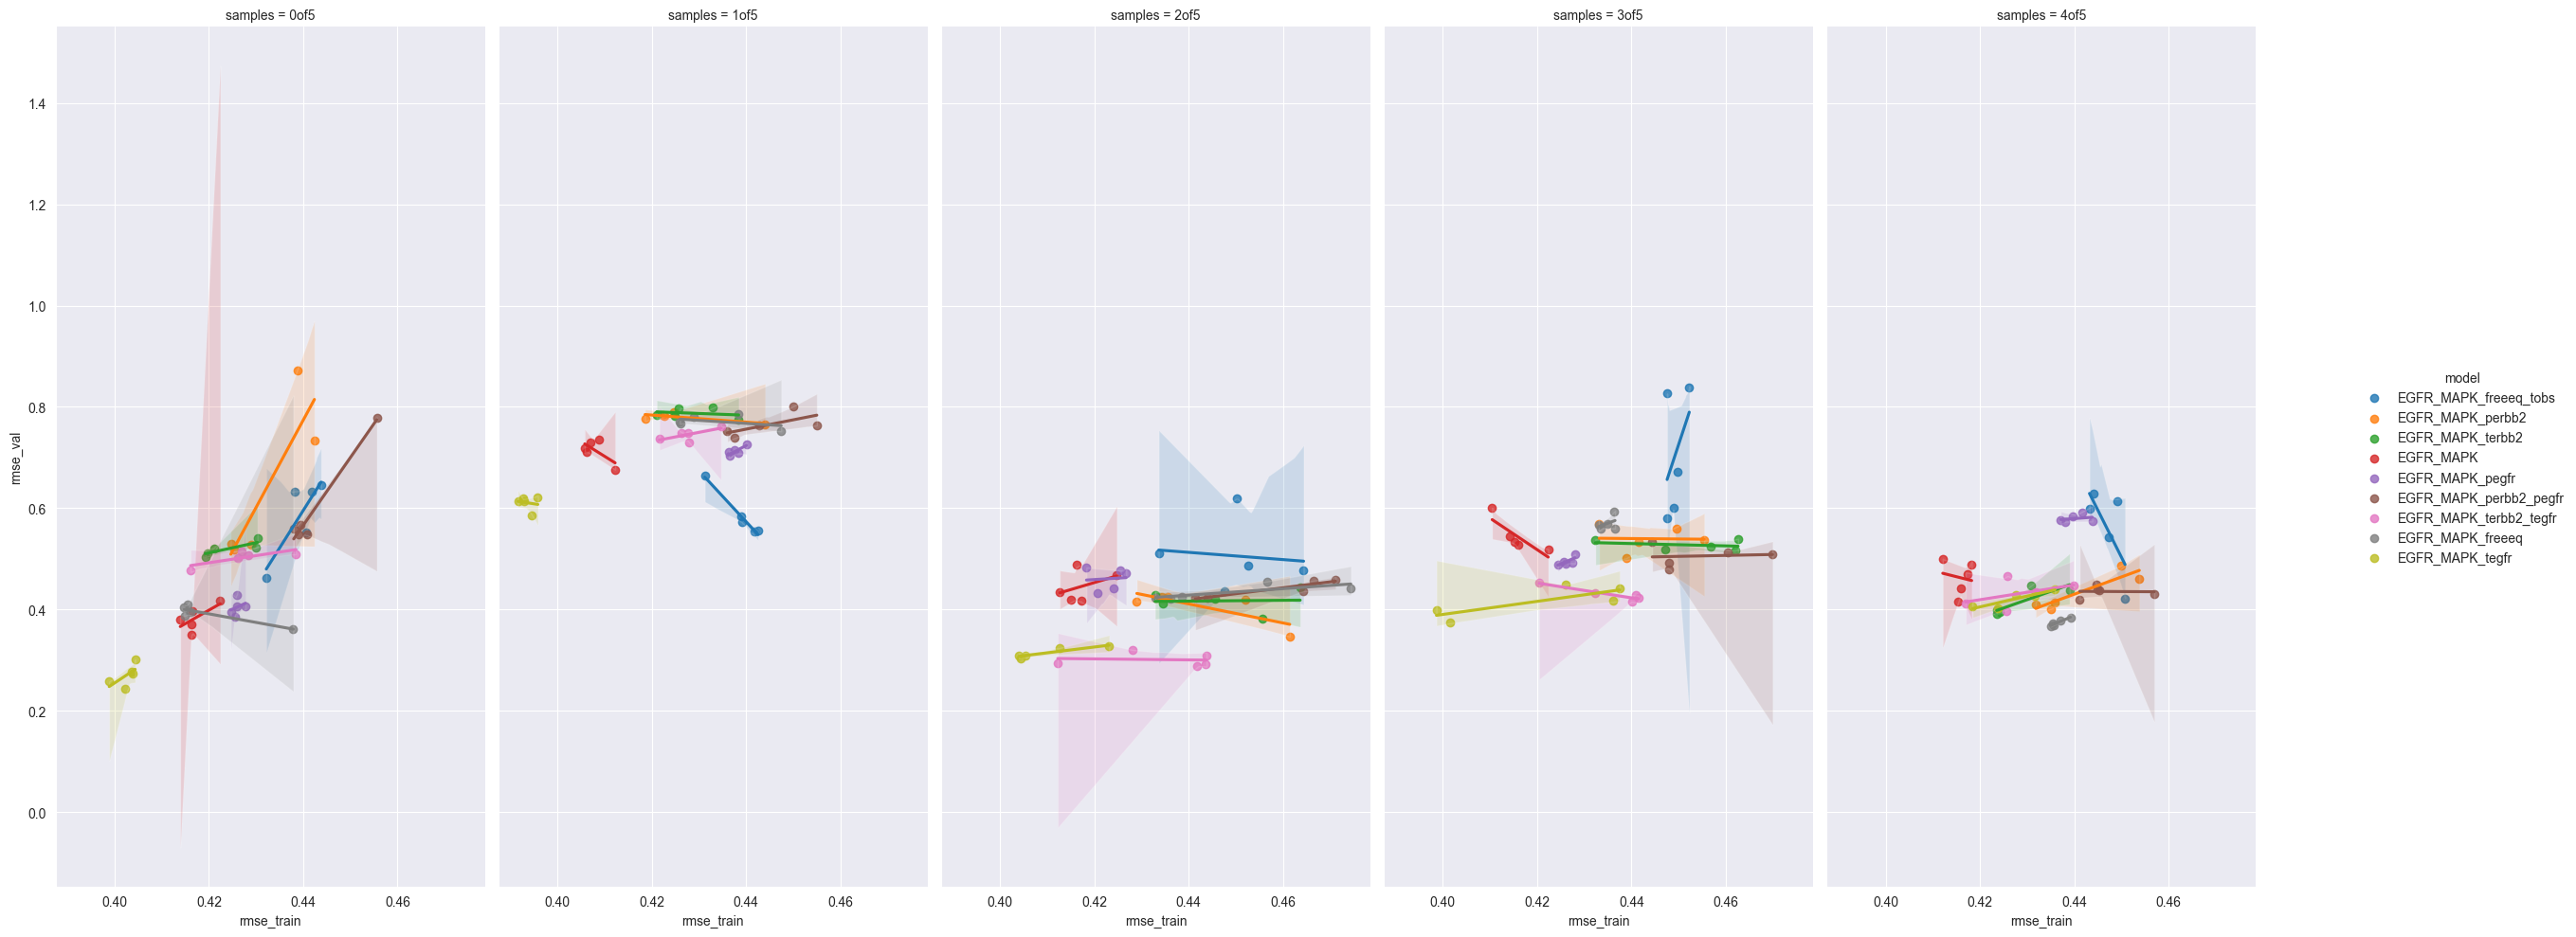

In [38]:
sns.lmplot(
    data=df[df['step']==499],
    x='rmse_train',
    y='rmse_val',
    col='samples',
    col_order=sorted(df['samples'].unique()),
    hue='model',
    height=10,
    aspect=0.5,
    facet_kws={'margin_titles': True, 'sharey': True, 'sharex': True},
)

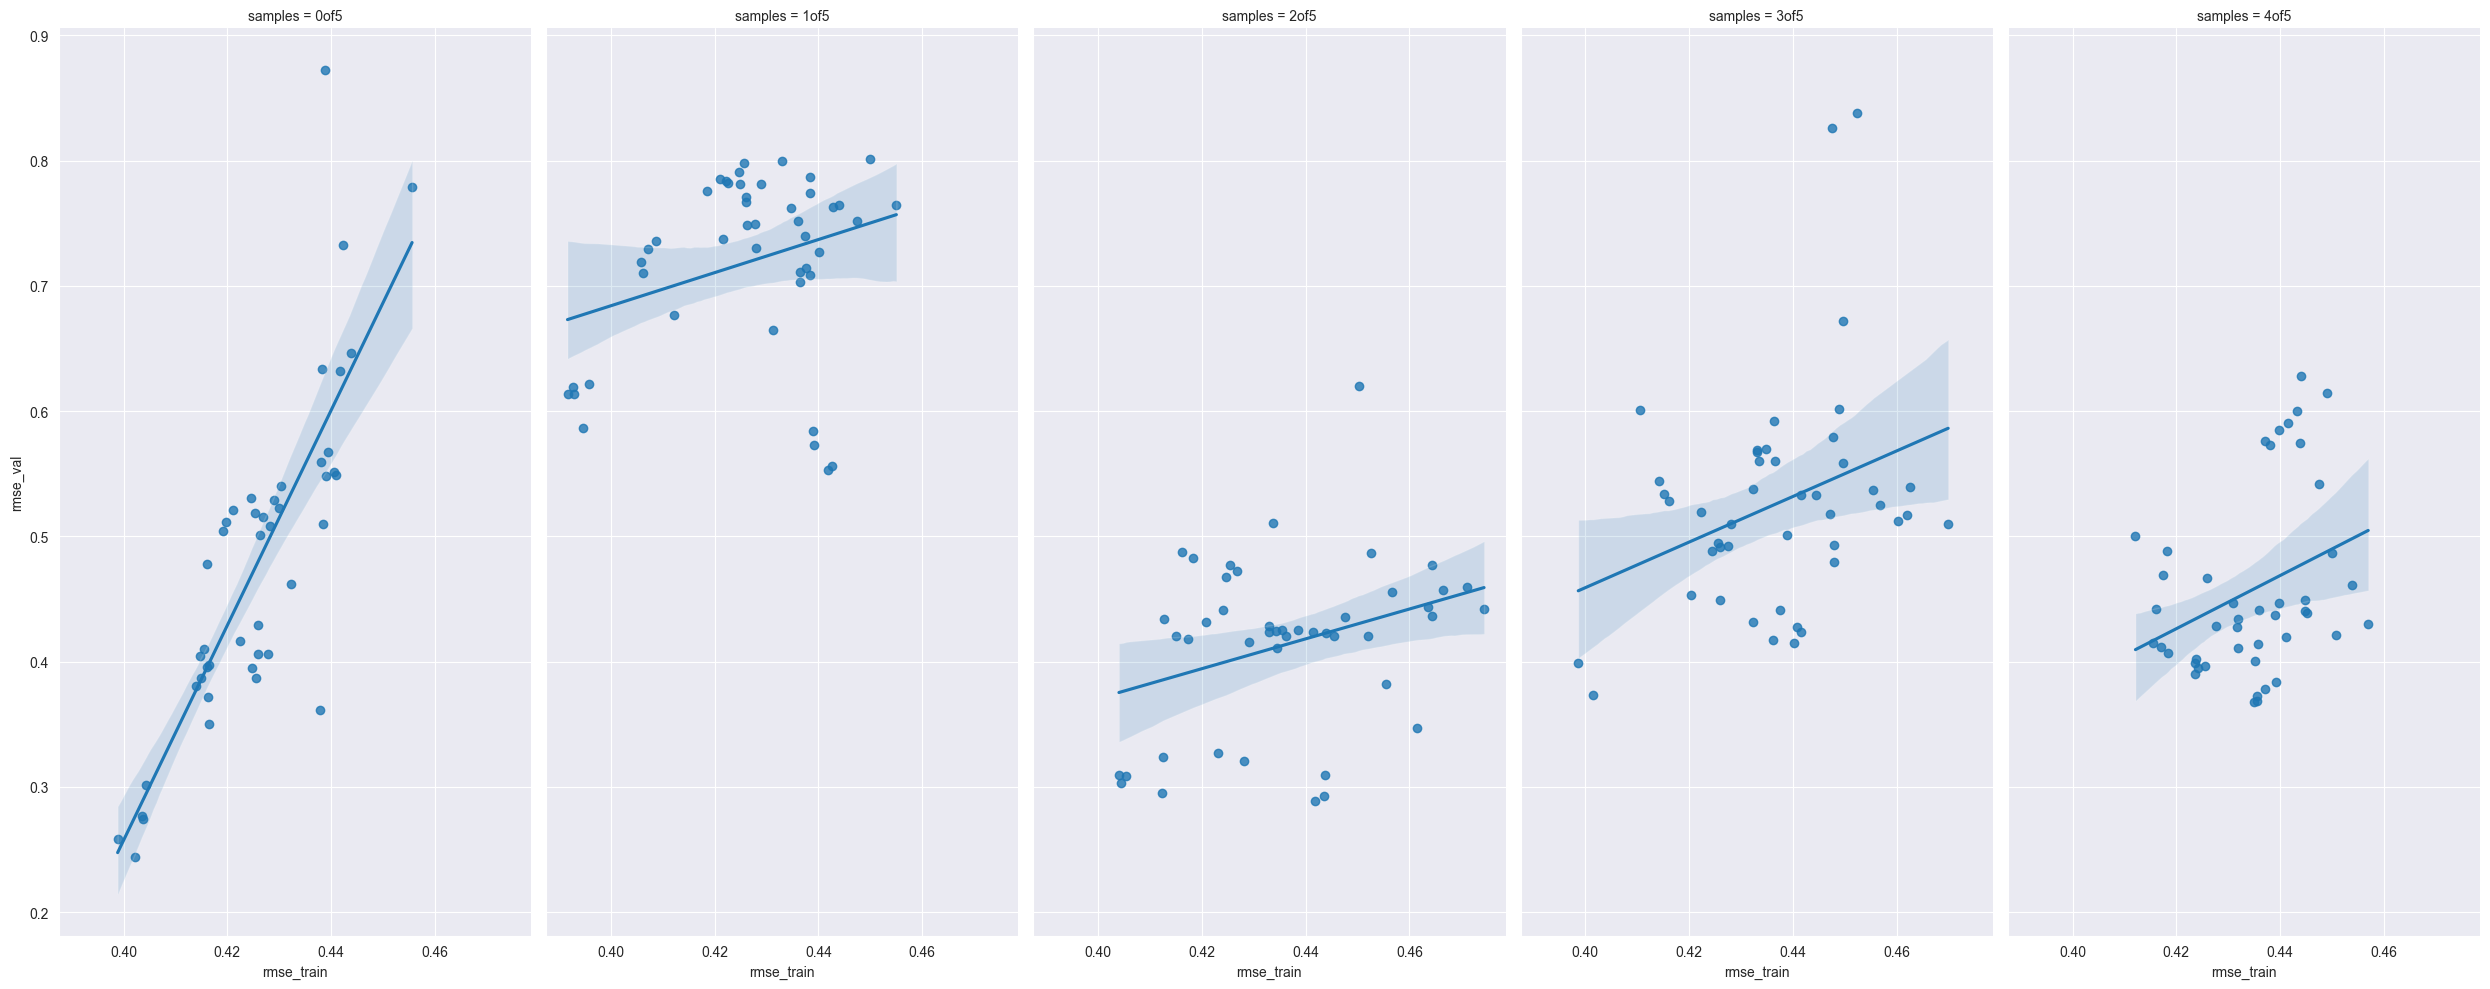

In [39]:
sns.lmplot(
    data=df[df['step']==499],
    x='rmse_train',
    y='rmse_val',
    col='samples',
    col_order=sorted(df['samples'].unique()),
    height=10,
    aspect=0.5,
    facet_kws={'margin_titles': True, 'sharey': True, 'sharex': True},
)

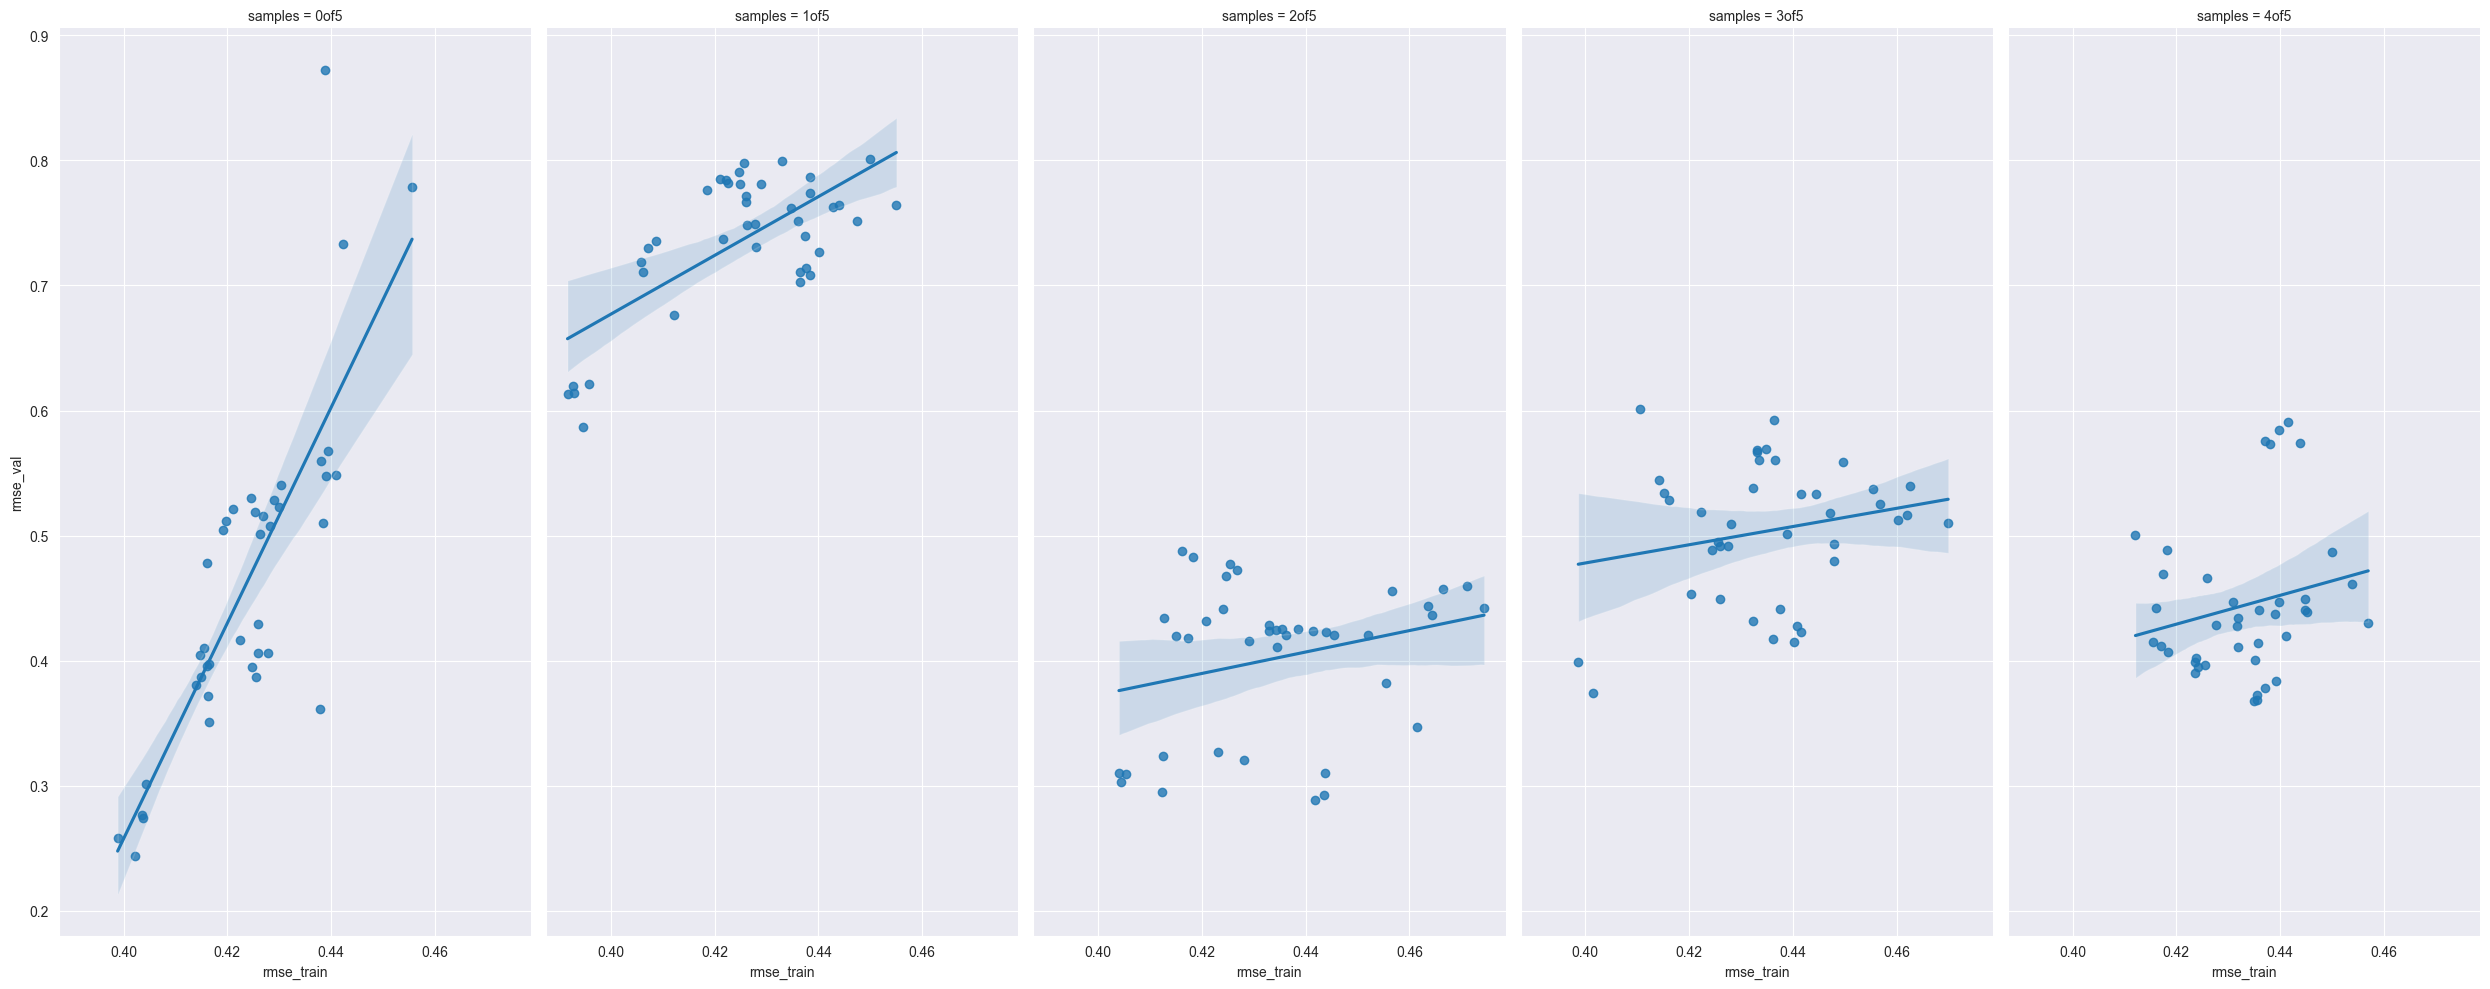

In [40]:
sns.lmplot(
    data=df[(df['step']==499) & (df['model']!='EGFR_MAPK_freeeq_tobs')],
    x='rmse_train',
    y='rmse_val',
    col='samples',
    col_order=sorted(df['samples'].unique()),
    height=10,
    aspect=0.5,
    facet_kws={'margin_titles': True, 'sharey': True, 'sharex': True},
)

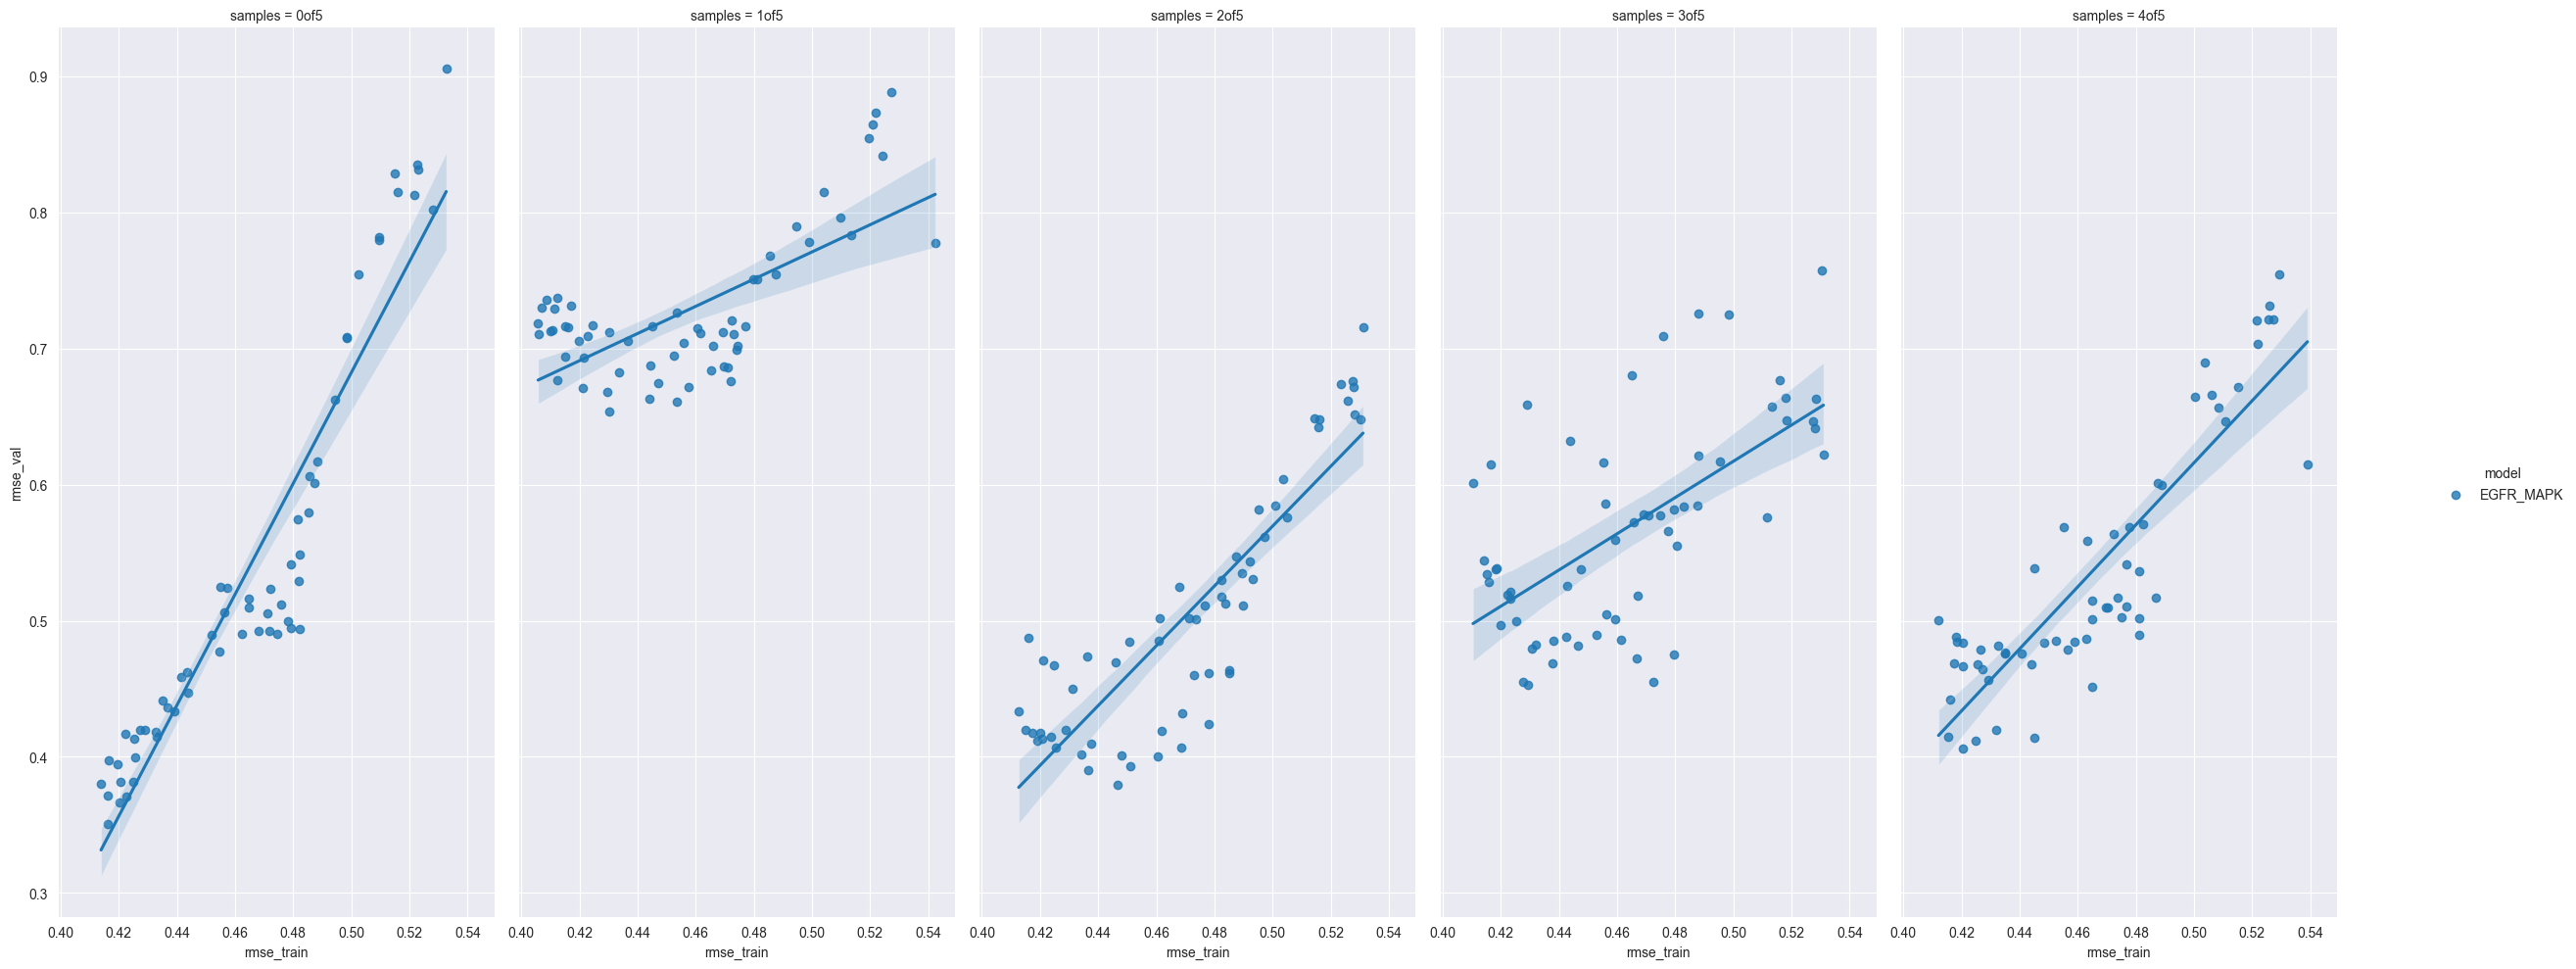

In [41]:
sns.lmplot(
    data=df[df['model']=='EGFR_MAPK'],
    x='rmse_train',
    y='rmse_val',
    col='samples',
    col_order=sorted(df['samples'].unique()),
    hue='model',
    height=10,
    aspect=0.5,
    facet_kws={'margin_titles': True, 'sharey': True, 'sharex': True},
)